<a href="https://colab.research.google.com/github/yuliuwen/Uncertainpy/blob/master/AgentModelImplementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -i https://test.pypi.org/simple/ uncertainpy2
!git clone https://github.com/marcocuccarini/Legal_Argument_Modelling

!cd Legal_Argument_Modelling

import sys
sys.path.append("/content/Legal_Argument_Modelling")  # or your local path
import uncertainpy2.gradual as grad
import networkx as nx
from classes.ArgumentationGraph import *
import uncertainpy2.gradual as grad




Looking in indexes: https://test.pypi.org/simple/
fatal: destination path 'Legal_Argument_Modelling' already exists and is not an empty directory.


In [ ]:
%matplotlib inline

# 1 Graph

In [ ]:
BAG = grad.BAG()
#initialization


dec_father = grad.Argument("Father", 0.5)
dec_mother = grad.Argument("Mother", 0.5)


BAG.add_attack(dec_father, dec_mother)
BAG.add_attack(dec_mother, dec_father)

e_pm1 = grad.Argument("pm1", 0.9)
sup_epm1_decmother = BAG.add_support(e_pm1, dec_mother, 0.9)


e_pm2 = grad.Argument("pm2", 0.8)
BAG.add_support(e_pm2, dec_mother, 0.8)

e_cm1 = grad.Argument("cm1", 0.5)
BAG.add_attack(e_cm1, dec_mother, 0.5)

e_ppm1 = grad.Argument("ppm1", 0.9)
BAG.add_support(e_ppm1, sup_epm1_decmother, 0.9)

e_cf1 = grad.Argument("cf1", 0.8)
BAG.add_attack(e_cf1, dec_father, 0.8)
e_cf2 = grad.Argument("cf2", 0.7)
BAG.add_attack(e_cf2, dec_father, 0.7)
e_cf3 = grad.Argument("cf3", 0.7)
BAG.add_attack(e_cf3, dec_father, 0.7)

e_pcf2 = grad.Argument("pcf2", 0.8)
BAG.add_support(e_pcf2, e_cf2, 0.7)

Sup(pcf2, cf2):0.7->0.7

In [ ]:
model = grad.semantics.ContinuousDFQuADModel()
model.BAG = BAG

model.approximator = grad.algorithms.RK4(model)
DELTA = 10e-2
EPSILON = 10e-4
result = model.solve(DELTA, EPSILON, True, True)


ContinuousDFQuADModel, RK4
Time: 7.699999999999989
Arg(Father):0.5->0.006
Arg(Mother):0.5->0.851
Arg(pm1):0.9->0.9
Sup(pm1, Mother):0.9->0.981
Arg(pm2):0.8->0.8
Arg(cm1):0.5->0.5
Arg(ppm1):0.9->0.9
Arg(cf1):0.8->0.8
Arg(cf2):0.7->0.868
Arg(cf3):0.7->0.7
Arg(pcf2):0.8->0.8



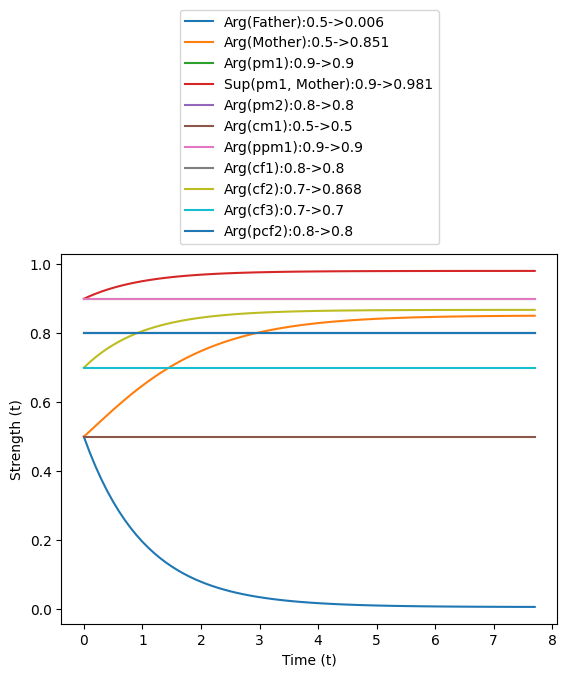

In [ ]:

plot = grad.plotting.strengthplot(model, DELTA, EPSILON)
plt.title('')
plt.legend(bbox_to_anchor=(0.5, 1.68), loc='upper center')
plot.show()

# 2 Graph

In [ ]:
# Initialization of the graph
BAG = grad.BAG()

# --- MAIN ARGUMENTS (DECISIONS) ---
# M: Give custody to the mother (score 0.50)
dec_mother = grad.Argument("M", 0.5)

# F: Give custody to the father (score 0.50)
dec_father = grad.Argument("F", 0.5)

# Mutual attack between Mother and Father (2 relations)
BAG.add_attack(dec_father, dec_mother)
BAG.add_attack(dec_mother, dec_father)


# --- LEFT SIDE: ARGUMENTS RELATED TO THE MOTHER (M) ---

# PPM1: The children are old enough (0.40)
ppm1 = grad.Argument("PPM1", 0.4)

# PM1: The children want to live with the Mother (0.20)
pm1 = grad.Argument("PM1", 0.2)

# PM2: The educational environment aptitude is average (0.30)
pm2 = grad.Argument("PM2", 0.3)

# CM1: Mother moved the children without the father's knowledge or consent (0.90)
cm1 = grad.Argument("CM1", 0.9)

# CCM1: The German court found the move to N. to be illegal (0.90)
ccm1 = grad.Argument("CCM1", 0.9)

# CCF2: Mother's alienation (0.90)
ccf2 = grad.Argument("CCF2", 0.9)

# Supports toward mother decision / mother-side (5 relations total in this block)
BAG.add_support(ppm1, pm1, 0.10)        # PPM1 -> PM1 (0.10)
BAG.add_support(pm1, dec_mother, 0.20)  # PM1  -> M   (0.20)
BAG.add_support(pm2, dec_mother, 0.20)  # PM2  -> M   (0.20)

# Attacks toward mother decision (3 relations)
BAG.add_attack(cm1, dec_mother, 0.80)   # CM1  -> M   (0.80)
BAG.add_attack(ccm1, dec_mother, 0.80)  # CCM1 -> M   (0.80)
BAG.add_attack(ccf2, dec_mother, 0.80)  # CCF2 -> M   (0.80)

# Internal / cross relations involving CCM1 and CCF2 (4 relations)
BAG.add_attack(cm1, ccm1, 0.70)         # CM1  -> CCM1 (0.70)
BAG.add_support(cm1, ccf2, 0.70)        # CM1  -> CCF2 (0.70)
BAG.add_support(ppm1, ccf2, 0.60)       # PPM1 -> CCF2 (0.60)
BAG.add_support(pm1, ccf2, 0.60)        # PM1  -> CCF2 (0.60)


# --- RIGHT SIDE: ARGUMENTS RELATED TO THE FATHER (F) ---

# CF1: The educational environment aptitude is weaker than average (0.30)
cf1 = grad.Argument("CF1", 0.3)

# CF2: Children have bad attitude to father (0.20)
cf2 = grad.Argument("CF2", 0.2)

# CF3: Father tried to influence the children and involve them in the conflict (0.30)
cf3 = grad.Argument("CF3", 0.3)

# PCF2: They add their own bad experience (0.20)
pcf2 = grad.Argument("PCF2", 0.2)

# Attacks toward father decision (3 relations)
BAG.add_attack(cf1, dec_father, 0.20)   # CF1 -> F (0.20)
BAG.add_attack(cf2, dec_father, 0.20)   # CF2 -> F (0.20)
BAG.add_attack(cf3, dec_father, 0.30)   # CF3 -> F (0.30)

# Internal father-side relations (2 relations)
BAG.add_support(pcf2, cf3, 0.30)        # PCF2 -> CF3 (0.30)
BAG.add_attack(ccf2, cf3, 0.80)         # CCF2 -> CF3 (0.80)


Att(CCF2, CF3):0.8->0.8

In [ ]:
model = grad.semantics.ContinuousDFQuADModel()
model.BAG = BAG

model.approximator = grad.algorithms.RK4(model)
DELTA = 10e-2
EPSILON = 10e-4
result = model.solve(DELTA, EPSILON, True, True)

ContinuousDFQuADModel, RK4
Time: 7.29999999999999
Arg(F):0.5->0.41
Arg(M):0.5->0.065
Arg(PPM1):0.4->0.4
Arg(PM1):0.2->0.232
Arg(PM2):0.3->0.3
Arg(CM1):0.9->0.9
Arg(CCM1):0.9->0.333
Arg(CCF2):0.9->0.976
Arg(CF1):0.3->0.3
Arg(CF2):0.2->0.2
Arg(CF3):0.3->0.084
Arg(PCF2):0.2->0.2



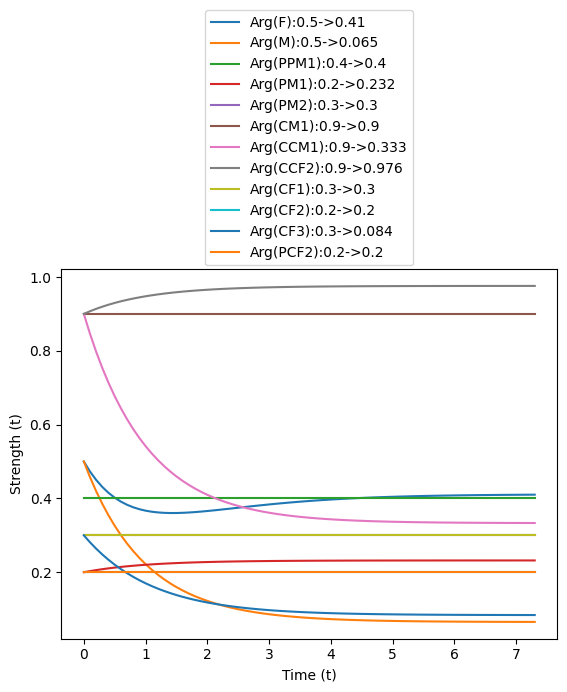

In [ ]:
plot = grad.plotting.strengthplot(model, DELTA, EPSILON)
plt.title('')
plt.legend(bbox_to_anchor=(0.5, 1.72), loc='upper center')
plot.show()

# 3 Graph

In [ ]:
# Initialization of the graph
BAG = grad.BAG()

# --- MAIN DECISIONS ---
M = grad.Argument("M", 0.50)
F = grad.Argument("F", 0.50)

# Mutual attack between M and F (2 edges)
BAG.add_attack(M, F)
BAG.add_attack(F, M)


# --- LEFT / MOTHER-SIDE ARGUMENTS ---
PPM1 = grad.Argument("PPM1", 0.90)
PM1  = grad.Argument("PM1",  0.90)
PM2  = grad.Argument("PM2",  0.80)
CM1  = grad.Argument("CM1",  0.50)
CCM1 = grad.Argument("CCM1", 0.90)
CCF2 = grad.Argument("CCF2", 0.50)

# Supports into M (3 edges)
BAG.add_support(PPM1, M, 0.90)   # PPM1 -> M
BAG.add_support(PM1,  M, 0.90)   # PM1  -> M
BAG.add_support(PM2,  M, 0.80)   # PM2  -> M

# M attacks CCM1 (1 edge)
BAG.add_attack(M, CCM1, 0.80)    # M -> CCM1

# CM1 supports CCM1 (1 edge)
BAG.add_support(CM1, CCM1, 0.50) # CM1 -> CCM1

# CM1 supports CCF2 (1 edge, dashed .20)
BAG.add_support(CM1, CCF2, 0.20) # CM1 -> CCF2

# M attacks CCF2 (1 edge, solid .80 diagonal)
BAG.add_attack(M, CCF2, 0.80)    # M -> CCF2

# TWO long curved edges of weight 0.2 from CCF2 (2 edges)
BAG.add_attack(CCF2, PPM1, 0.20) # CCF2 -> PPM1  (curved 0.2)
BAG.add_attack(CCF2, M,    0.20) # CCF2 -> M     (curved 0.2)


# --- RIGHT / FATHER-SIDE ARGUMENTS ---
CF1  = grad.Argument("CF1",  0.80)
CF2  = grad.Argument("CF2",  0.70)
CF3  = grad.Argument("CF3",  0.70)
CF4  = grad.Argument("CF4",  0.90)
PCF2 = grad.Argument("PCF2", 0.10)
CF5  = grad.Argument("CF5",  0.90)

# Attacks into F (4 edges)
BAG.add_attack(CF1, F, 0.80)     # CF1 -> F
BAG.add_attack(CF2, F, 0.70)     # CF2 -> F
BAG.add_attack(CF3, F, 0.70)     # CF3 -> F
BAG.add_attack(CF4, F, 0.90)     # CF4 -> F

# CCF2 also attacks F (1 edge, 0.30)
BAG.add_attack(CCF2, F, 0.30)    # CCF2 -> F

# CCF2 attacks CF3 (1 edge, 0.50)
BAG.add_attack(CCF2, CF3, 0.50)  # CCF2 -> CF3

# PCF2 supports CF3 (1 edge, 0.10 dashed)
BAG.add_support(PCF2, CF3, 0.10) # PCF2 -> CF3

# CF5 attacks PCF2 (1 edge, 0.90 left arrow)
BAG.add_attack(CF5, PCF2, 0.90)  # CF5 -> PCF2

# CCF2 attacks CF5 (1 edge, 0.80 long curved)
BAG.add_attack(CCF2, CF5, 0.80)  # CCF2 -> CF5

Att(CCF2, CF5):0.8->0.8

In [ ]:
model = grad.semantics.ContinuousDFQuADModel()
model.BAG = BAG

model.approximator = grad.algorithms.RK4(model)
DELTA = 10e-2
EPSILON = 10e-4
result = model.solve(DELTA, EPSILON, True, True)


ContinuousDFQuADModel, RK4
Time: 9.99999999999998
Arg(M):0.5->0.976
Arg(F):0.5->0.0
Arg(PPM1):0.9->0.871
Arg(PM1):0.9->0.9
Arg(PM2):0.8->0.8
Arg(CCM1):0.9->0.423
Arg(CM1):0.5->0.5
Arg(CCF2):0.5->0.16
Arg(CF1):0.8->0.8
Arg(CF2):0.7->0.7
Arg(CF3):0.7->0.646
Arg(CF4):0.9->0.9
Arg(PCF2):0.1->0.03
Arg(CF5):0.9->0.784



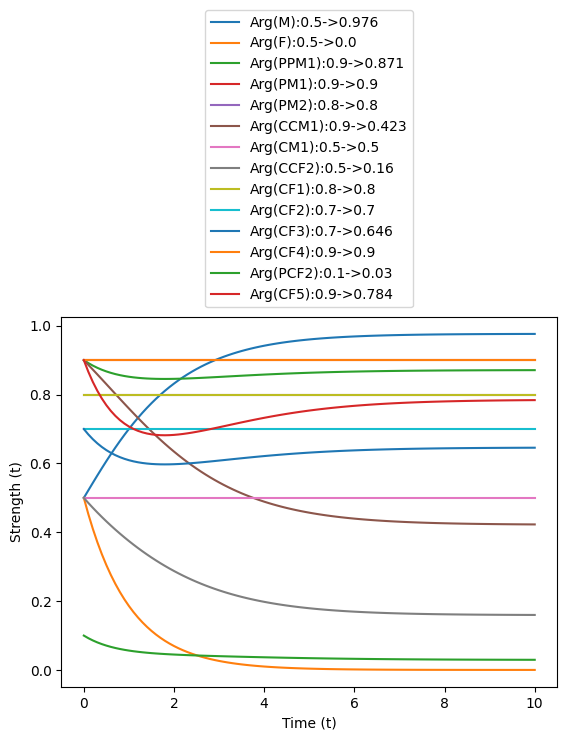

In [ ]:
plot = grad.plotting.strengthplot(model, DELTA, EPSILON)
plt.title('')
plt.legend(bbox_to_anchor=(0.5, 1.85), loc='upper center')
plot.show()